*This notebook is about a tricky little problem (E10.10) from David Williams' excellent Probability with Martingales*
# The Star-Ship Enterprise Problem
The control system on the star-ship *Enterprise* has gone wonky. All that one can do is set a distance to be travelled. The spaceship will then move that distance in a randomly chosen direction, then stop. The object is to get into the Solar System, a ball of radius $r$. Intially, the *Enterprise* is at a distance $R_0(>r)$ from the Sun. 

Let $R_n$ be the distance from the Sun to *Enterprise* after $n$ 'space-hops'. Use Gauss's theorems on potentials due to spherically-symmetric charge distributions to show that whatever strategy is adopted, $1/R_n$ is a *supermartingale*, and that for any strategy which always sets a distance no greater than that from the Sun to *Enterprise*, $1/R_n$ is a *martingale*. Use (E10.9) to show that 
$$
P(\text{\emph{Enterprise} gets into the Solar System}) \le \frac{r}{R_0}
$$
For each $\epsilon > 0$, you can choose a strategy which makes this probability greater than $(r/R_0) - \epsilon$. What kind of strategy will this be?

# The Solution

## Part 1
Let's first prove that $1/R_n$ is a (super)martingale. For notational ease, let $X_n$ be the position of enterprise in $\mathbb{R}^3$, and let $C_{n}$ be a pre-visible process that is our hop-length. 

This question isn't difficult, as long as you know what is meant by Gauss's theorem on potentials. First, let's let $V(x)$ be an electric potential, where there is a single point charge at $0$. This is our Sun. We have the following Poisson Equation:
$$
\Delta V(x) = -4\pi\delta_0(x)
$$
From PDEs it is known that the unique solution to this, in $\mathbb{R}^3$, is the Green's function for the Laplacian:
$$
V(x) = \frac1{|x|}
$$
where we neglect constants.

Now, we let $\xi \sim \mathrm{Unif}(S^2) = \frac{S}{4\pi}$, where $S$ is the surface area measure. Then we are interested in:
$$
\frac1{4\pi}\int_{\partial B} V(X_n + C_n \xi) dS(\xi)
$$
Whenever we are integrating over a shell, we should always think of co-area formula. So, let's try and get an integration over the radius. 
We can get:
$$
V(X_n + C_n \xi) - V(X_n) = \int_{0}^{C_n} \nabla V(X_n + r \xi) \cdot \xi dr 
$$
Plugging this in, we have:
$$
\frac{1}{4\pi}\int_{\partial B} \int_0^{C_n} \nabla V(X_n + r \xi) \cdot \xi dr dS(\xi) + V(X_n)
$$
Let's make a change of variable, $x = X_n + r\xi$. Then $dS(x) = r^2 dS(\xi)$. This gives us:
$$
\frac{1}{4\pi}\int_0^{C_n} \frac1{r^2}\int_{\partial B(X_n, r)} \nabla V(x) \cdot \xi  dS(\xi)dr + \frac1{R_n}
$$
Then, recalling the divergence theorem, we have:
$$
\frac1{4\pi} \int_0^{C_n} \frac1{r^2}\int_{B(X_n, r)} \nabla \cdot \nabla V(x) dx dr + \frac1{R_n} = \frac1{4\pi} \int_0^{C_n} \frac1{r^2} \int_{B(X_n, r)} \Delta V(x) dx dr + \frac1{R_n}
$$
Then plugging in $\Delta V(x) = -4\pi\delta_0(x)$ 
$$
\int_{R_n}^{C_n} -\frac1{r^2} dr + \frac1{R_n} = \left(\frac1{C_n} - \frac1{R_n}\right)\lor 0 + \frac1{R_n}
$$
We see that if $C_n > R_n$, then $\frac{1}{R_n}$ is a supermartingale, since 
$$
E\left[\frac{1}{R_{n + 1}} \bigg| \frac1{R_n}\right] = \frac1{C_n} < \frac1{R_n}
$$
And if $C_n \le R_n$, then we have it's clearly a martingale. 


## Part 2
Now we look at the second part of the question. 

Here is what E10.9 says:
Let $X$ be a non-negative super martingale. Let $T$ be a stopping time. Then
$$
E[X_T ; T < \infty] \le E[X_0]
$$
The proof for this isn't hard. We have 
$$
E[X_{T \land n}] \le E[X_0]
$$
Then by Fatou's lemma
$$
E[X_T ; T < \infty] \le E[X_T] = E[ \lim\inf_n X_{T\land n}] \le \lim\inf_n E[X_{T\land n}] \le E[X_0]
$$. 

The necessary corollary is then: For any $c \ge 0$, we have:
$$
c\Pr[\sup_n X_n \ge c] \le E[X_0]
$$
Again the proof is pretty easy. Let 
$$
T = \inf_n \{X_n \ge c\}
$$
Then, 
$$
E[X_0] \ge E[X_T ; T < \infty] \ge c E[T < \infty] = c \Pr[\exists n : X_n \ge  c] = c \Pr[\sup_n X_n \ge c]
$$

Now that we have the lemma, it is very easy to show what we want. Let $T = \inf_n \{R_n < r\}$. Then 
$$
\frac1{r} P(T < \infty) \le E\left[\frac1{R_T}; T < \infty\right] \le \frac1{R_0}
$$
So, we have
$$
P(T < \infty) \le \frac{r}{R_0}
$$

## Part 3
The last part is much more difficult. The idea is as follows.

Let $M_n = \frac1{R_n}$ and let $T = \inf_n \{ R_n \le r\}$. Then the idea is we look at the following object
$$
P[M_T ; T < \infty] \le M_0
$$
But we want to make it so $M_T$ is actually as small as possible, because we are working against this upper bound. If $M_T$ were big, then $P[T < \infty]$ would necessarily have to be pretty small. So the goal is to have $\rho \le R_T \le r$ for $\rho$ close to $r$. Specifically, we want 
$$
P[T<\infty] \approx \frac{\rho}{R_0} \ge \frac{r}{R_0} - \epsilon
$$
so we just choose $\rho = r - \epsilon R_0$. Now, it's clear that we just want to jump to $\rho$, so we define our hop-length to be $R_{n} - \rho$. Since our hop length is less than $R_{n}$, $M_n$ is indeed a martingale. Here's the tricky part, if that wasn't already tricky. We want to show
$$
\frac1{R_0} = E[M_T; T < \infty] \le \frac1{\rho} P(T < \infty)
$$
The way I did it is as follows:

My idea is to leverage stopped martingales. We have
$$
\frac1{R_0} = E[M_{n \land T}] = E[M_{n \land T} ; T < \infty] + E[M_{n} ; T = \infty]
$$
Then, since our stopped martingales are bounded by $\frac1{\rho}$ we can apply dominated convergence to get our result. The problem is the second term. It's quite difficult to show that it goes to 0. The idea is that if it isn't hitting the ball of radius $r$, then it surely must be diverging to infinity. Here was the way I solved it, I'm curious if anyone has a simpler way. 

Instead of doing the naive breakdown above, we define two auxiliary stopping times: 
$$
\tau_K := \inf_n \{R_n \ge K\} \qquad \tau:= \tau_K \land T
$$
then we have:
$$
\frac1{R_0} = E[M_{n \land \tau}] = E[M_{n \land \tau_K} ; \tau_K < T] + E[M_{n \land T}; T < \tau_K]
$$
The former term should go to zero, and the latter term should go to what we want. The former term goes to 0 because we should have:
$$
\lim_{n \to\infty} E[M_{n \land \tau_K}; \tau_K < T] = E[M_{\tau_K}; \tau_K < T] \le \frac{P[\tau_K < T]}{K}
$$
However, this relies on the fact that $\tau_K < \infty$ on the set $\tau_K < T$. This is tricky to prove. However, I will show it. 

We use the following lemma. 
Let $T$ be a stopping time w.r.t $\mathcal{F}_n$ such that there exists $N$ and $\epsilon > 0$ such that for all $n$, we have:
$$
P[T \le n + N | \mathcal{F}_n] > \epsilon
$$
Then $E[T] < \infty$. 

The proof is simple and quick, so I will present it. 

We have
$$
\begin{align*}
P(T > n + N| \mathcal{F}_n) &\le 1 - \epsilon \\
P(T > kN) &= P(T > kN; T > (k - 1)N)\\
&= P(T > kN| T > (k - 1)N ) P(T > (k - 1)N)\\
&= P(T > (k-1)N + N | \mathcal{F}_{(k-1)N}) P(T > (k - 1)N)\\
&\le (1-\epsilon) (1 - \epsilon)^{k-1} = (1 - \epsilon)^k
\end{align*}
$$
Therefore, 
$$
\begin{align*}
E[T] &= \sum_{k = 0}^\infty P(T > k)\\
P(T > kN + i) &\le P(T > kN)\\
\implies E[T] &\le N\sum_{k = 0}^\infty P(T > kN) \\
&\le N \sum_{k = 0}^\infty (1 - \epsilon)^k = \frac{N}{\epsilon}\\
\end{align*}
$$
Which finishes the proof

How do we use this lemma? Simple. On the set $\tau_K < T$, and $n < \tau_K$, we have that 
$$
r < R_n < K
$$
Additionally, each hop length is lower bounded by $r - \rho =: h$. Now, I'll paint a picture. We want our spaceship to land on a sector that has small angle. 

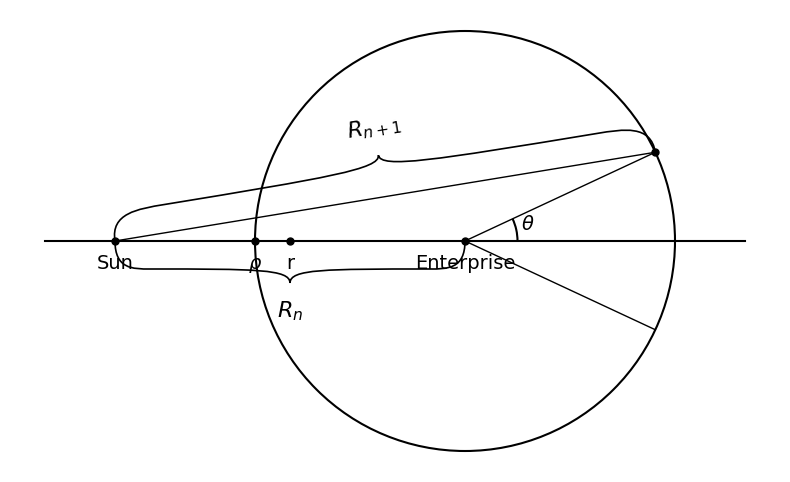

WLOG, let this angle $\theta \le \frac{\pi}{3}$, so that $\cos(\theta) \ge \frac12$. Clearly, the enterprise lands in this sector with some positive probability $p$. 
Now, we can calculate a lower bound for $R_{n+1}$. We have:
$$
\begin{align*} 
R_{n+1}^2 &= (R_n + h\cos(\theta))^2 + (h \sin(\theta))^2 = R_n^2 + 2R_n h\cos(\theta) + h^2\\
&= R_n^2\left(1 + 2 \frac{h \cos(\theta)}{R_n} + \frac{h^2}{R_n^2}\right) \ge R_n^2 \left(1 + \frac{h}{R_n} + \frac{h^2}{R_n^2}\right)\ge R_n^2\left(1 + \frac{h}{r} + \frac{h^2}{r^2}\right) =: R_n^2 \delta^2
\end{align*}
$$
Clearly, $\delta > 1$, so we have 
$$
R_{n+N} \ge R_n \delta^N
$$
and for large enough $N$, we have 
$$
P(R_{n + N} \ge K | R_n) > p^N > 0
$$
so by our lemma, we have that $E[\tau_K] < \infty$, which means that $\tau_K$ is finite almost surely. 


Now, we can use this. We have:
$$
\begin{align*}
\lim_{n \to \infty} E[M_{n \land \tau_K};\tau_K < T] = E[M_{\tau_K} ; \tau_K < T] \le \frac{P(\tau_K < T)}{K}\\
\lim_{n \to \infty} E[M_{n \land T} ; T < \tau_K] = \lim_{n \to \infty} E[M_{T} ; T < \tau_K] \le \frac{P(T < \tau_K)}{\rho}
\end{align*}
$$
Plugging these in, we have:
$$
\frac1{R_0} \le \frac{P(\tau_K < T)}{K} + \frac{P(T < \tau_K)}{\rho}
$$
The rest is easy now. We take $K \to \infty$, and the first term on the right goes to 0, and for the second, we have:
$$
P(T < \tau_K) \le P(T < \infty)
$$
So finally, we have:
$$
\frac{r}{R_0} - \epsilon = \frac{\rho}{R_0} \le P(T < \infty)
$$
